In [152]:
import pandas as pd
import numpy as np

In [153]:
df=pd.DataFrame()

In [154]:
df['X1'] = [1,2,3,4,5,6,6,7,9,9]
df['X2'] = [5,3,6,8,1,9,5,8,9,2]
df['label'] = [1,1,0,1,0,1,0,1,0,0]

In [155]:
df

,X1,X2,label
0,1,5,1
1,2,3,1
2,3,6,0
3,4,8,1
4,5,1,0
5,6,9,1
6,6,5,0
7,7,8,1
8,9,9,0
9,9,2,0


In [156]:
df['weights'] = 1/df.shape[0]

In [157]:
df

,X1,X2,label,weights
0,1,5,1,0.1
1,2,3,1,0.1
2,3,6,0,0.1
3,4,8,1,0.1
4,5,1,0,0.1
5,6,9,1,0.1
6,6,5,0,0.1
7,7,8,1,0.1
8,9,9,0,0.1
9,9,2,0,0.1


<Axes: xlabel='X1', ylabel='X2'>

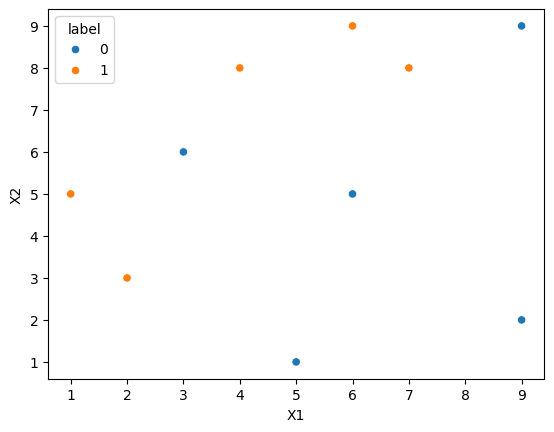

In [158]:
import seaborn as sns 
sns.scatterplot(x=df['X1'],y=df['X2'],hue=df['label'])

In [159]:
from sklearn.tree import DecisionTreeClassifier

In [160]:
model=DecisionTreeClassifier(max_depth=1)

In [161]:
X=df.iloc[:,0:2].values
Y=df.iloc[:,2].values

In [162]:
model.fit(X,Y)

DecisionTreeClassifier(max_depth=1)

In [163]:
from sklearn.tree import plot_tree

[Text(0.5, 0.75, 'x[1] <= 2.5\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.469\nsamples = 8\nvalue = [3, 5]'),
 Text(0.625, 0.5, '  False')]

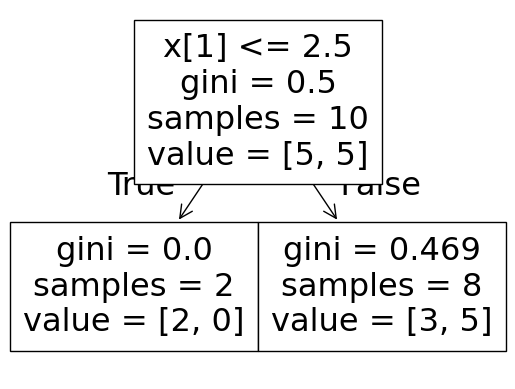

In [164]:
plot_tree(model)

In [165]:
df['y_pred']=model.predict(X)

In [166]:
df

,X1,X2,label,weights,y_pred
0,1,5,1,0.1,1
1,2,3,1,0.1,1
2,3,6,0,0.1,1
3,4,8,1,0.1,1
4,5,1,0,0.1,0
5,6,9,1,0.1,1
6,6,5,0,0.1,1
7,7,8,1,0.1,1
8,9,9,0,0.1,1
9,9,2,0,0.1,0


In [167]:
def calculate_error(error):
    return (0.5)*np.log((1-error)/(error+0.000001))

In [168]:
alpha1=calculate_error(0.3)

In [169]:
alpha1

0.42364726352971294

In [170]:
def update_new_weight(row,alpha=0.423):
    if row['label']==row['y_pred']:
        return row['weights']*np.exp(-alpha)
    else:
        return row['weights']*np.exp(alpha)

In [171]:
df['updated_weight']=df.apply(update_new_weight,axis=1)

In [172]:
df

,X1,X2,label,weights,y_pred,updated_weight
0,1,5,1,0.1,1,0.065508
1,2,3,1,0.1,1,0.065508
2,3,6,0,0.1,1,0.152653
3,4,8,1,0.1,1,0.065508
4,5,1,0,0.1,0,0.065508
5,6,9,1,0.1,1,0.065508
6,6,5,0,0.1,1,0.152653
7,7,8,1,0.1,1,0.065508
8,9,9,0,0.1,1,0.152653
9,9,2,0,0.1,0,0.065508


In [173]:
df['updated_weight'].sum()

0.9165153319682015

In [174]:
df['normalized']=df['updated_weight']/df['updated_weight'].sum()

In [175]:
df

,X1,X2,label,weights,y_pred,updated_weight,normalized
0,1,5,1,0.1,1,0.065508,0.071475
1,2,3,1,0.1,1,0.065508,0.071475
2,3,6,0,0.1,1,0.152653,0.166559
3,4,8,1,0.1,1,0.065508,0.071475
4,5,1,0,0.1,0,0.065508,0.071475
5,6,9,1,0.1,1,0.065508,0.071475
6,6,5,0,0.1,1,0.152653,0.166559
7,7,8,1,0.1,1,0.065508,0.071475
8,9,9,0,0.1,1,0.152653,0.166559
9,9,2,0,0.1,0,0.065508,0.071475


In [176]:
df['normalized'].sum()

1.0

In [177]:
df['cumsum_upper']=np.cumsum(df['normalized'])

In [178]:
df['cumsum_lower']=df['cumsum_upper']-df['normalized']

In [179]:
df

,X1,X2,label,weights,y_pred,updated_weight,normalized,cumsum_upper,cumsum_lower
0,1,5,1,0.1,1,0.065508,0.071475,0.071475,0.000000
1,2,3,1,0.1,1,0.065508,0.071475,0.142950,0.071475
2,3,6,0,0.1,1,0.152653,0.166559,0.309508,0.142950
3,4,8,1,0.1,1,0.065508,0.071475,0.380983,0.309508
4,5,1,0,0.1,0,0.065508,0.071475,0.452458,0.380983
5,6,9,1,0.1,1,0.065508,0.071475,0.523933,0.452458
6,6,5,0,0.1,1,0.152653,0.166559,0.690492,0.523933
7,7,8,1,0.1,1,0.065508,0.071475,0.761967,0.690492
8,9,9,0,0.1,1,0.152653,0.166559,0.928525,0.761967
9,9,2,0,0.1,0,0.065508,0.071475,1.000000,0.928525


In [180]:
def create_new_dataset(df):

  indices = []

  for i in range(df.shape[0]):
    a = np.random.random()
    for index,row in df.iterrows():
      if row['cumsum_upper'] > a and a > row['cumsum_lower']:
        indices.append(index)
  return indices

In [181]:
index_values = create_new_dataset(df)

index_values
     

[8, 8, 1, 8, 2, 4, 1, 4, 3, 6]

In [182]:
second_df=df.iloc[index_values,[0,1,2,3]]

In [183]:
second_df

,X1,X2,label,weights
8,9,9,0,0.1
8,9,9,0,0.1
1,2,3,1,0.1
8,9,9,0,0.1
2,3,6,0,0.1
4,5,1,0,0.1
1,2,3,1,0.1
4,5,1,0,0.1
3,4,8,1,0.1
6,6,5,0,0.1


In [184]:
model2=DecisionTreeClassifier(max_depth=1)

In [185]:
X=df.iloc[:,0:2].values
Y=df.iloc[:,2].values

In [186]:
model2.fit(X,Y)

DecisionTreeClassifier(max_depth=1)

[Text(0.5, 0.75, 'x[0] <= 2.5\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.469\nsamples = 8\nvalue = [5, 3]'),
 Text(0.625, 0.5, '  False')]

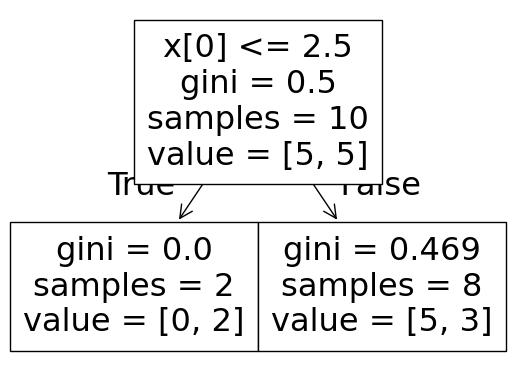

In [187]:
plot_tree(model2)

In [188]:
second_df['y_pred'] = model2.predict(X)

In [189]:
second_df

,X1,X2,label,weights,y_pred
8,9,9,0,0.1,1
8,9,9,0,0.1,1
1,2,3,1,0.1,0
8,9,9,0,0.1,0
2,3,6,0,0.1,0
4,5,1,0,0.1,0
1,2,3,1,0.1,0
4,5,1,0,0.1,0
3,4,8,1,0.1,0
6,6,5,0,0.1,0


In [190]:
alpha2 = calculate_error(0.3)
     

In [191]:
alpha2

0.42364726352971294

In [192]:
def update_new_weight(row,alpha=0.423):
    if row['label']==row['y_pred']:
        return row['weights']*np.exp(-alpha)
    else:
        return row['weights']*np.exp(alpha)

In [193]:
second_df['updated_weights'] = second_df.apply(update_new_weight,axis=1)
     

second_df
     

,X1,X2,label,weights,y_pred,updated_weights
8,9,9,0,0.1,1,0.152653
8,9,9,0,0.1,1,0.152653
1,2,3,1,0.1,0,0.152653
8,9,9,0,0.1,0,0.065508
2,3,6,0,0.1,0,0.065508
4,5,1,0,0.1,0,0.065508
1,2,3,1,0.1,0,0.152653
4,5,1,0,0.1,0,0.065508
3,4,8,1,0.1,0,0.152653
6,6,5,0,0.1,0,0.065508


In [194]:
second_df['nomalized_weights'] = second_df['updated_weights']/second_df['updated_weights'].sum()
second_df

,X1,X2,label,weights,y_pred,updated_weights,nomalized_weights
8,9,9,0,0.1,1,0.152653,0.139945
8,9,9,0,0.1,1,0.152653,0.139945
1,2,3,1,0.1,0,0.152653,0.139945
8,9,9,0,0.1,0,0.065508,0.060055
2,3,6,0,0.1,0,0.065508,0.060055
4,5,1,0,0.1,0,0.065508,0.060055
1,2,3,1,0.1,0,0.152653,0.139945
4,5,1,0,0.1,0,0.065508,0.060055
3,4,8,1,0.1,0,0.152653,0.139945
6,6,5,0,0.1,0,0.065508,0.060055


In [195]:
second_df['cumsum_upper'] = np.cumsum(second_df['nomalized_weights'])
second_df['cumsum_lower'] = second_df['cumsum_upper'] - second_df['nomalized_weights']
     

In [196]:
second_df


,X1,X2,label,weights,y_pred,updated_weights,nomalized_weights,cumsum_upper,cumsum_lower
8,9,9,0,0.1,1,0.152653,0.139945,0.139945,0.000000
8,9,9,0,0.1,1,0.152653,0.139945,0.279891,0.139945
1,2,3,1,0.1,0,0.152653,0.139945,0.419836,0.279891
8,9,9,0,0.1,0,0.065508,0.060055,0.479891,0.419836
2,3,6,0,0.1,0,0.065508,0.060055,0.539945,0.479891
4,5,1,0,0.1,0,0.065508,0.060055,0.600000,0.539945
1,2,3,1,0.1,0,0.152653,0.139945,0.739945,0.600000
4,5,1,0,0.1,0,0.065508,0.060055,0.800000,0.739945
3,4,8,1,0.1,0,0.152653,0.139945,0.939945,0.800000
6,6,5,0,0.1,0,0.065508,0.060055,1.000000,0.939945


In [197]:
index_values = create_new_dataset(second_df)
third_df = second_df.iloc[index_values,[0,1,2,3]]
third_df

,X1,X2,label,weights
3,4,8,1,0.1
3,4,8,1,0.1
8,9,9,0,0.1
8,9,9,0,0.1
2,3,6,0,0.1
3,4,8,1,0.1
3,4,8,1,0.1
8,9,9,0,0.1
3,4,8,1,0.1
3,4,8,1,0.1


In [198]:
model3= DecisionTreeClassifier(max_depth=1)

X = second_df.iloc[:,0:2].values
y = second_df.iloc[:,2].values

model3.fit(X,y)

DecisionTreeClassifier(max_depth=1)

In [199]:
third_df['y_pred'] = model3.predict(X)

In [200]:
third_df

,X1,X2,label,weights,y_pred
3,4,8,1,0.1,0
3,4,8,1,0.1,0
8,9,9,0,0.1,1
8,9,9,0,0.1,0
2,3,6,0,0.1,1
3,4,8,1,0.1,0
3,4,8,1,0.1,1
8,9,9,0,0.1,0
3,4,8,1,0.1,1
3,4,8,1,0.1,0


In [201]:
alpha3 = calculate_error(0.5)
alpha3

-9.999990000148213e-07

In [202]:
print(alpha1,alpha2,alpha3)

0.42364726352971294 0.42364726352971294 -9.999990000148213e-07


In [203]:
query = np.array([1,5]).reshape(1,2)
model.predict(query)

array([1], dtype=int64)

In [204]:
model2.predict(query)

array([1], dtype=int64)

In [205]:
model3.predict(query)

array([1], dtype=int64)

In [206]:
alpha1*1 + alpha2*(1) + alpha3*(1)

0.8472935270604258

In [207]:
np.sign(0.84729)

1.0

In [208]:
query = np.array([9,9]).reshape(1,2)
model.predict(query)

array([1], dtype=int64)

In [209]:
model2.predict(query)

array([0], dtype=int64)

In [210]:
model3.predict(query)

array([0], dtype=int64)

In [211]:
alpha1*(1) + alpha2*(-1) + alpha3*(-1)

9.999990000148213e-07

In [212]:
np.sin(9.999999999)

-0.5440211100502982